In [39]:
from dataclasses import dataclass
from typing import Dict, List, Tuple

from rich import box
from rich.console import Console, Group
from rich.panel import Panel
from rich.table import Table
from rich.text import Text


# =============================================================================
# Constants and unit conversions
# =============================================================================

C_M_S = 299_792_458.0
C_CM_S = C_M_S * 100.0


def nm_vac_to_THz(lambda_nm: float) -> float:
    return C_M_S / (lambda_nm * 1e-9) / 1e12


def THz_to_nm_vac(freq_THz: float) -> float:
    return C_M_S / (freq_THz * 1e12) * 1e9


def cm_to_THz(sigma_cm: float) -> float:
    return sigma_cm * C_CM_S / 1e12


def THz_to_cm(freq_THz: float) -> float:
    return freq_THz * 1e12 / C_CM_S


def MHz_to_THz(freq_MHz: float) -> float:
    return freq_MHz / 1e6


def THz_to_MHz(freq_THz: float) -> float:
    return freq_THz * 1e6



In [47]:
%matplotlib inline

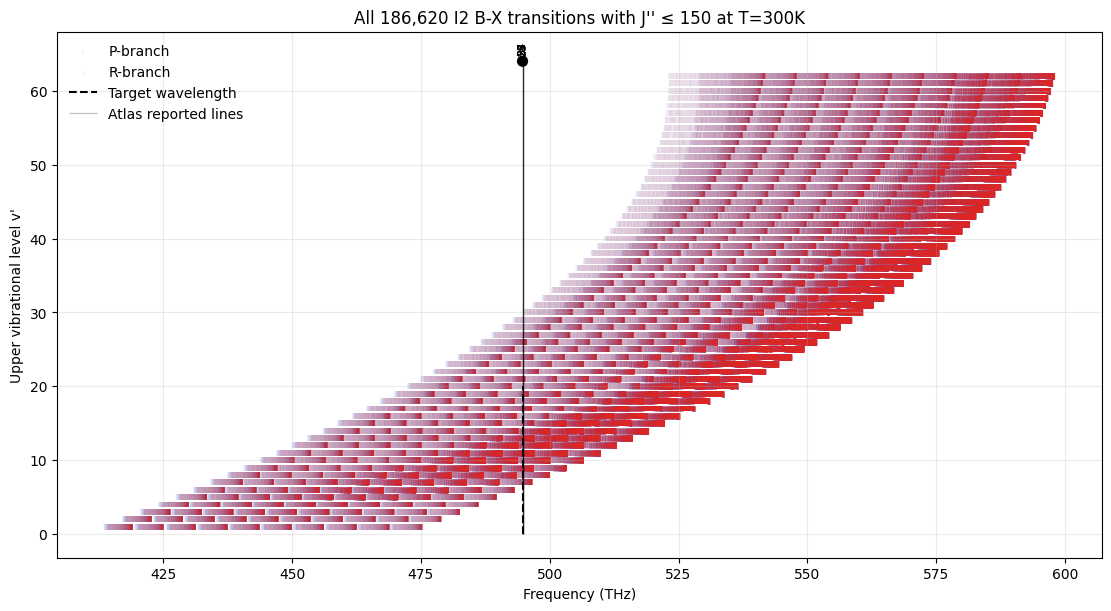

In [48]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


csv_candidates = [
    Path("iodine_bx_accurate_strengths_J150_T300.csv"),
    Path("PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv"),
    Path("../..") / "iodine_bx_accurate_strengths_J150_T300.csv",
    Path("../..") / "PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv",
]

for csv_path in csv_candidates:
    if csv_path.exists():
        break
else:
    raise FileNotFoundError("Could not find iodine_bx_accurate_strengths_J150_T300.csv")

transitions = pd.read_csv(csv_path)
transitions["strength_linewidth"] = 0.15 + 2.5 * np.sqrt(
    transitions["relative_strength_norm"].fillna(0.0).clip(lower=0.0)
)

fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)

COLOR_ACCURATE_P = "#2563EB"
COLOR_ACCURATE_R = "#DC2626"
branch_colors = {"P": COLOR_ACCURATE_P, "R": COLOR_ACCURATE_R}
for branch, group in transitions.groupby("branch", sort=True):
    ax.scatter(
        group["frequency_THz"],
        group["v_upper"],
        marker="|",
        s=18,
        linewidths=group["strength_linewidth"],
        alpha=0.5,
        color=branch_colors.get(branch, "tab:gray"),
        label=f"{branch}-branch",
        rasterized=True,
    )

ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Upper vibrational level v'")
ax.set_title(f"All {len(transitions):,} I2 B-X transitions with J'' ≤ 150 at T=300K")
ax.grid(alpha=0.25)
ax.vlines(nm_vac_to_THz(605.9770), 0, 20, color="black", linestyle="--", label="Target wavelength")

atlas_transitions_freq = [cm_to_THz(16501.9321), cm_to_THz(16502.0125), cm_to_THz(16502.4381), cm_to_THz(16502.5983), cm_to_THz(16502.8396), cm_to_THz(16502.9160)]
atlas_transitions_str = [23, 52, 27, 25, 34, 18]
atlas_strength_max = max(atlas_transitions_str)
atlas_y = transitions["v_upper"].max() + 2
atlas_marker_sizes = [35 + 165 * strength / atlas_strength_max for strength in atlas_transitions_str]

ax.vlines(atlas_transitions_freq, 0, atlas_y, color="black", alpha=0.25, linewidth=0.9, label="Atlas reported lines")
ax.scatter(
    atlas_transitions_freq,
    [atlas_y] * len(atlas_transitions_freq),
    s=atlas_marker_sizes,
    color="black",
    marker=".",
    zorder=5,
)
for freq_THz, strength in zip(atlas_transitions_freq, atlas_transitions_str):
    ax.text(freq_THz, atlas_y + 0.8, str(strength), ha="center", va="bottom", fontsize=8, rotation=90)

ax.set_ylim(top=atlas_y + 4)
ax.legend(frameon=False)

plt.show()

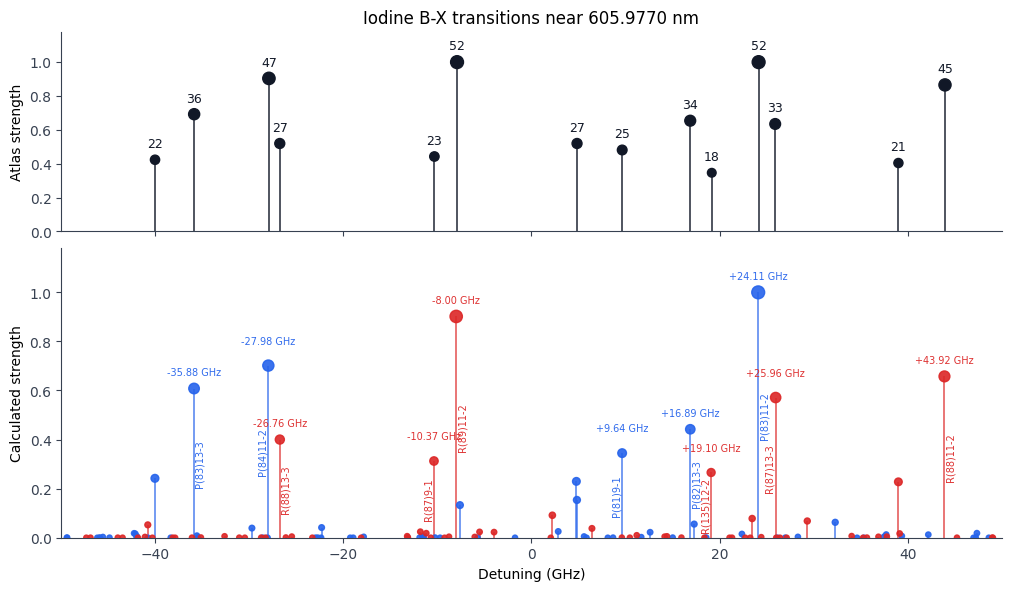

In [85]:
# Production plot: atlas reported lines vs accurate calculated strengths.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# Adjustable plot settings.
TARGET_NM_VAC = 605.9770 #THz_to_nm_vac(539.390405756) #THz_to_nm_vac(593.670)  #605.9770
DETUNING_LIMIT_GHZ = 50.0
LABEL_STRENGTH_THRESHOLD = 0.26

# Adjustable colors, all hexadecimal.
COLOR_ATLAS = "#111827"
COLOR_ACCURATE_P = "#2563EB"
COLOR_ACCURATE_R = "#DC2626"
COLOR_TARGET = "#374151"
COLOR_GRID = "#D1D5DB"
COLOR_AXIS = "#374151"
COLOR_TEXT = "#111827"
COLOR_BACKGROUND = "#FFFFFF"


if "cm_to_THz" not in globals():
    C_CM_S = 299_792_458.0 * 100.0

    def cm_to_THz(sigma_cm: float) -> float:
        return sigma_cm * C_CM_S / 1e12


if "nm_vac_to_THz" not in globals():
    def nm_vac_to_THz(lambda_nm: float) -> float:
        return 299_792_458.0 / (lambda_nm * 1e-9) / 1e12


def find_existing_file(candidates, description):
    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(f"Could not find {description}")


accurate_csv_path = find_existing_file(
    [
        Path("iodine_bx_accurate_strengths_J150_T300.csv"),
        Path("PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv"),
        Path("../..") / "iodine_bx_accurate_strengths_J150_T300.csv",
        Path("../..") / "PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv",
    ],
    "iodine_bx_accurate_strengths_J150_T300.csv",
)
atlas_csv_path = find_existing_file(
    [
        Path("I2_atlas_lines_14800-20000.csv"),
        Path("PhaseStab/Iodine/I2_atlas_lines_14800-20000.csv"),
        Path("../..") / "I2_atlas_lines_14800-20000.csv",
        Path("../..") / "PhaseStab/Iodine/I2_atlas_lines_14800-20000.csv",
    ],
    "I2_atlas_lines_14800-20000.csv",
)

target_freq_THz = nm_vac_to_THz(TARGET_NM_VAC)

atlas_df = pd.read_csv(atlas_csv_path)
atlas_df["detuning_GHz"] = (atlas_df["frequency_THz"] - target_freq_THz) * 1e3
atlas_window = atlas_df[atlas_df["detuning_GHz"].between(-DETUNING_LIMIT_GHZ, DETUNING_LIMIT_GHZ)].copy()
if atlas_window.empty:
    raise ValueError("No atlas transitions found within +/-30 GHz of the target")
atlas_window["relative_strength"] = atlas_window["strength"] / atlas_window["strength"].max()

accurate_df = pd.read_csv(accurate_csv_path)
accurate_df["detuning_GHz"] = (accurate_df["frequency_THz"] - target_freq_THz) * 1e3
accurate_window = accurate_df[
    accurate_df["detuning_GHz"].between(-DETUNING_LIMIT_GHZ, DETUNING_LIMIT_GHZ)
].copy()

if accurate_window.empty:
    raise ValueError("No accurate calculated transitions found within +/-30 GHz of the target")

accurate_window["relative_strength_window"] = (
    accurate_window["relative_strength"] / accurate_window["relative_strength"].max()
)
accurate_window["transition_label"] = accurate_window.apply(
    lambda row: f"{row['branch']}({int(row['J_lower'])}){int(row['v_upper'])}-{int(row['v_lower'])}",
    axis=1,
)

fig, (ax_atlas, ax_calc) = plt.subplots(
    2,
    1,
    figsize=(10, 5.8),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1.0, 1.45]},
)
fig.patch.set_facecolor(COLOR_BACKGROUND)

for axis in (ax_atlas, ax_calc):
    axis.set_facecolor(COLOR_BACKGROUND)
    #axis.axvline(0.0, color=COLOR_TARGET, linewidth=1.2, linestyle="--", alpha=0.85)
    axis.set_xlim(-DETUNING_LIMIT_GHZ, DETUNING_LIMIT_GHZ)
    axis.set_ylim(0.0, 1.18)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_color(COLOR_AXIS)
    axis.spines["bottom"].set_color(COLOR_AXIS)
    axis.tick_params(colors=COLOR_AXIS)

ax_atlas.vlines(
    atlas_window["detuning_GHz"],
    0.0,
    atlas_window["relative_strength"],
    color=COLOR_ATLAS,
    linewidth=1.15,
    alpha=0.9,
)
ax_atlas.scatter(
    atlas_window["detuning_GHz"],
    atlas_window["relative_strength"],
    s=14 + 72 * atlas_window["relative_strength"],
    color=COLOR_ATLAS,
    zorder=3,
)
for row in atlas_window.itertuples(index=False):
    ax_atlas.text(
        row.detuning_GHz,
        row.relative_strength + 0.055,
        f"{int(row.strength)}",
        color=COLOR_TEXT,
        ha="center",
        va="bottom",
        fontsize=9,
    )

branch_colors = {"P": COLOR_ACCURATE_P, "R": COLOR_ACCURATE_R}
for branch, group in accurate_window.groupby("branch", sort=True):
    color = branch_colors.get(branch, COLOR_AXIS)
    ax_calc.vlines(
        group["detuning_GHz"],
        0.0,
        group["relative_strength_window"],
        color=color,
        linewidth=1.15,
        alpha=0.78,
        label=f"{branch}-branch",
    )
    ax_calc.scatter(
        group["detuning_GHz"],
        group["relative_strength_window"],
        s=14 + 72 * group["relative_strength_window"],
        color=color,
        alpha=0.9,
        zorder=3,
    )

labeled_transitions = accurate_window[
    accurate_window["relative_strength_window"] >= LABEL_STRENGTH_THRESHOLD
].sort_values("detuning_GHz")
for i, row in enumerate(labeled_transitions.itertuples(index=False)):
    color = branch_colors.get(row.branch, COLOR_AXIS)
    x_offset = 0.62 if i % 2 == 0 else -0.62
    ax_calc.text(
        row.detuning_GHz + x_offset,
        row.relative_strength_window * 0.5,
        row.transition_label,
        rotation=90,
        color=color,
        ha="center",
        va="center",
        fontsize=7,
        alpha=0.95,
    )
    ax_calc.text(
        row.detuning_GHz,
        min(row.relative_strength_window + 0.045 + 0.035 * (i % 2), 1.14),
        f"{row.detuning_GHz:+.2f} GHz",
        color=color,
        ha="center",
        va="bottom",
        fontsize=7,
        alpha=0.95,
    )

ax_atlas.set_ylabel("Atlas strength")
ax_calc.set_ylabel("Calculated strength")
ax_calc.set_xlabel(f"Detuning (GHz)")
ax_atlas.set_title(f"Iodine B-X transitions near {TARGET_NM_VAC:.4f} nm")
#ax_calc.legend(frameon=False, loc="upper left", ncols=2)

plt.show()

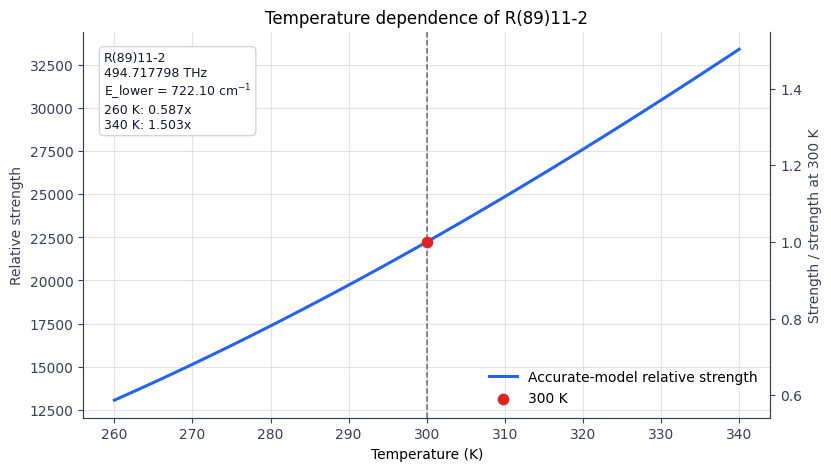

In [ ]:
# Temperature sweep for the accurate-model strength of R(89)11-2.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Adjustable settings.
T_CENTER_K = 300.0
T_HALF_RANGE_K = 40.0
N_TEMPERATURES = 161

TRANSITION_BRANCH = "R"
TRANSITION_J_LOWER = 89
TRANSITION_V_UPPER = 11
TRANSITION_V_LOWER = 2

# Adjustable colors, all hexadecimal.
COLOR_STRENGTH = "#2563EB"
COLOR_POINT = "#DC2626"
COLOR_REFERENCE = "#374151"
COLOR_GRID = "#D1D5DB"
COLOR_AXIS = "#374151"
COLOR_TEXT = "#111827"
COLOR_BACKGROUND = "#FFFFFF"

K_B_OVER_HC_CM = 0.695034800  # cm^-1 K^-1


def find_existing_file(candidates, description):
    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(f"Could not find {description}")


accurate_csv_path = find_existing_file(
    [
        Path("iodine_bx_accurate_strengths_J150_T300.csv"),
        Path("PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv"),
        Path("../..") / "PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv",
        Path("../..") / "iodine_bx_accurate_strengths_J150_T300.csv",
    ],
    "iodine_bx_accurate_strengths_J150_T300.csv",
)

accurate_df = pd.read_csv(accurate_csv_path)
transition_row = accurate_df[
    (accurate_df["branch"] == TRANSITION_BRANCH)
    & (accurate_df["J_lower"] == TRANSITION_J_LOWER)
    & (accurate_df["v_upper"] == TRANSITION_V_UPPER)
    & (accurate_df["v_lower"] == TRANSITION_V_LOWER)
]

if transition_row.empty:
    raise ValueError("Could not find the requested transition in the accurate-strength CSV")
if len(transition_row) > 1:
    raise ValueError("Found more than one matching transition; please tighten the selector")

transition = transition_row.iloc[0]
transition_label = (
    f"{transition['branch']}({int(transition['J_lower'])})"
    f"{int(transition['v_upper'])}-{int(transition['v_lower'])}"
)

temperatures_K = np.linspace(
    T_CENTER_K - T_HALF_RANGE_K,
    T_CENTER_K + T_HALF_RANGE_K,
    N_TEMPERATURES,
)

# The accurate-strength CSV convention is:
# relative_strength = constant_factors * exp(-E_lower / kT).
# Keep the non-thermal factors from the CSV and sweep only the Boltzmann factor.
E_lower_cm = float(transition["E_lower_cm-1"])
strength_without_boltzmann = float(transition["relative_strength"]) / float(transition["boltzmann"])
boltzmann_vs_T = np.exp(-E_lower_cm / (K_B_OVER_HC_CM * temperatures_K))
strength_vs_T = strength_without_boltzmann * boltzmann_vs_T

strength_at_center = float(
    strength_without_boltzmann
    * np.exp(-E_lower_cm / (K_B_OVER_HC_CM * T_CENTER_K))
)
strength_ratio_to_center = strength_vs_T / strength_at_center

fig, ax = plt.subplots(figsize=(8.2, 4.6), constrained_layout=True)
fig.patch.set_facecolor(COLOR_BACKGROUND)
ax.set_facecolor(COLOR_BACKGROUND)

ax.plot(
    temperatures_K,
    strength_vs_T,
    color=COLOR_STRENGTH,
    linewidth=2.2,
    label="Accurate-model relative strength",
)
ax.scatter(
    [T_CENTER_K],
    [strength_at_center],
    color=COLOR_POINT,
    s=55,
    zorder=3,
    label=f"{T_CENTER_K:.0f} K",
)
ax.axvline(T_CENTER_K, color=COLOR_REFERENCE, linestyle="--", linewidth=1.1, alpha=0.75)

ax_ratio = ax.twinx()
ax_ratio.plot(
    temperatures_K,
    strength_ratio_to_center,
    color=COLOR_STRENGTH,
    alpha=0.0,
)

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Relative strength")
ax_ratio.set_ylabel(f"Strength / strength at {T_CENTER_K:.0f} K")
ax.set_title(f"Temperature dependence of {transition_label}")
ax.grid(color=COLOR_GRID, linewidth=0.8, alpha=0.65)

for axis in (ax, ax_ratio):
    axis.tick_params(colors=COLOR_AXIS)
    axis.yaxis.label.set_color(COLOR_AXIS)

for spine in ("top", "right", "bottom", "left"):
    ax.spines[spine].set_color(COLOR_AXIS)
    ax_ratio.spines[spine].set_color(COLOR_AXIS)
ax.spines["top"].set_visible(False)
ax_ratio.spines["top"].set_visible(False)

summary_text = (
    f"{transition_label}\n"
    f"{float(transition['frequency_THz']):.6f} THz\n"
    f"E_lower = {E_lower_cm:.2f} cm$^{{-1}}$\n"
    f"{T_CENTER_K - T_HALF_RANGE_K:.0f} K: {strength_ratio_to_center[0]:.3f}x\n"
    f"{T_CENTER_K + T_HALF_RANGE_K:.0f} K: {strength_ratio_to_center[-1]:.3f}x"
)
ax.text(
    0.03,
    0.95,
    summary_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    color=COLOR_TEXT,
    fontsize=9,
    bbox={"facecolor": COLOR_BACKGROUND, "edgecolor": COLOR_GRID, "boxstyle": "round,pad=0.35"},
)
ax.legend(frameon=False, loc="lower right")

plt.show()

In [74]:
# Rich lookup for one calculated I2 transition and the nearest atlas line.
from pathlib import Path
import re

import pandas as pd
from rich import box
from rich.console import Console, Group
from rich.panel import Panel
from rich.table import Table
from rich.text import Text


# Edit this line. Format: P(49)24-1 = branch P, J''=49, v'=24, v''=1.
TRANSITION_QUERY = "R(158)25-0"

# Leave as None to always report the closest atlas line. Set e.g. 5.0 to require a close match.
ATLAS_MAX_DETUNING_GHZ = None


def find_existing_file(candidates, description):
    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(f"Could not find {description}")


def parse_transition_query(query):
    compact_match = re.match(r"^\s*([PR])\s*\(\s*(\d+)\s*\)\s*(\d+)\s*-\s*(\d+)\s*$", query, re.IGNORECASE)
    spaced_match = re.match(r"^\s*([PR])\s+(\d+)\s+(\d+)\s+(\d+)\s*$", query, re.IGNORECASE)
    match = compact_match or spaced_match
    if not match:
        raise ValueError("Use a transition like 'P(49)24-1' or 'P 49 24 1'")

    branch, j_lower, v_upper, v_lower = match.groups()
    return branch.upper(), int(j_lower), int(v_upper), int(v_lower)


def fmt_float(value, decimals=6):
    return f"{float(value):.{decimals}f}"


def fmt_sci(value):
    return f"{float(value):.4e}"


accurate_csv_path = find_existing_file(
    [
        Path("iodine_bx_accurate_strengths_J150_T300.csv"),
        Path("PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv"),
        Path("../..") / "iodine_bx_accurate_strengths_J150_T300.csv",
        Path("../..") / "PhaseStab/Iodine/iodine_bx_accurate_strengths_J150_T300.csv",
    ],
    "iodine_bx_accurate_strengths_J150_T300.csv",
)
atlas_csv_path = find_existing_file(
    [
        Path("I2_atlas_lines_14800-20000.csv"),
        Path("PhaseStab/Iodine/I2_atlas_lines_14800-20000.csv"),
        Path("../..") / "I2_atlas_lines_14800-20000.csv",
        Path("../..") / "PhaseStab/Iodine/I2_atlas_lines_14800-20000.csv",
    ],
    "I2_atlas_lines_14800-20000.csv",
)

branch, j_lower, v_upper, v_lower = parse_transition_query(TRANSITION_QUERY)
transition_label = f"{branch}({j_lower}){v_upper}-{v_lower}"

model_df = pd.read_csv(accurate_csv_path)
model_rows = model_df[
    (model_df["branch"] == branch)
    & (model_df["J_lower"] == j_lower)
    & (model_df["v_upper"] == v_upper)
    & (model_df["v_lower"] == v_lower)
]
if model_rows.empty:
    raise ValueError(f"No calculated model transition found for {transition_label}")
if len(model_rows) > 1:
    raise ValueError(f"Found {len(model_rows)} model rows for {transition_label}; expected exactly one")

model = model_rows.iloc[0]
model_frequency_THz = float(model["frequency_THz"])
model_wavenumber_cm = float(model["wavenumber_cm-1"])

atlas_df = pd.read_csv(atlas_csv_path)
if "frequency_THz" not in atlas_df.columns:
    atlas_df["frequency_THz"] = atlas_df["wavenumber_cm-1"] * 0.0299792458
if "wavelength_vac_nm" not in atlas_df.columns:
    atlas_df["wavelength_vac_nm"] = 1e7 / atlas_df["wavenumber_cm-1"]

atlas_df["detuning_GHz"] = (atlas_df["frequency_THz"] - model_frequency_THz) * 1e3
atlas_df["detuning_cm-1"] = atlas_df["wavenumber_cm-1"] - model_wavenumber_cm
atlas_df["abs_detuning_GHz"] = atlas_df["detuning_GHz"].abs()

atlas_match = None
if not atlas_df.empty:
    nearest = atlas_df.loc[atlas_df["abs_detuning_GHz"].idxmin()]
    if ATLAS_MAX_DETUNING_GHZ is None or abs(float(nearest["detuning_GHz"])) <= ATLAS_MAX_DETUNING_GHZ:
        atlas_match = nearest

model_table = Table(title="Accurate Model", box=box.SIMPLE_HEAVY, show_header=True, header_style="bold cyan")
model_table.add_column("Quantity", style="bold")
model_table.add_column("Value", justify="right")
model_table.add_row("Transition", transition_label)
model_table.add_row("J'", str(int(model["J_upper"])))
model_table.add_row("Frequency", f"{fmt_float(model['frequency_THz'], 9)} THz")
model_table.add_row("Wavenumber", f"{fmt_float(model['wavenumber_cm-1'], 6)} cm^-1")
model_table.add_row("Vacuum wavelength", f"{fmt_float(model['wavelength_vac_nm'], 6)} nm")
model_table.add_row("Relative strength", fmt_sci(model["relative_strength"]))
model_table.add_row("Global normalized strength", fmt_sci(model["relative_strength_norm"]))
model_table.add_row("FCF", fmt_sci(model["FCF"]))
model_table.add_row("Boltzmann", fmt_sci(model["boltzmann"]))

atlas_table = Table(title="Nearest Atlas Line", box=box.SIMPLE_HEAVY, show_header=True, header_style="bold magenta")
atlas_table.add_column("Quantity", style="bold")
atlas_table.add_column("Value", justify="right")
if atlas_match is None:
    if atlas_df.empty:
        atlas_table.add_row("Atlas match", "No atlas rows available")
    else:
        atlas_table.add_row("Atlas match", f"None within {ATLAS_MAX_DETUNING_GHZ:.3g} GHz")
        atlas_table.add_row("Closest detuning", f"{float(nearest['detuning_GHz']):+.3f} GHz")
else:
    detuning_GHz = float(atlas_match["detuning_GHz"])
    detuning_style = "green" if abs(detuning_GHz) <= 1.0 else "yellow" if abs(detuning_GHz) <= 10.0 else "red"
    atlas_table.add_row("Atlas index N", str(int(atlas_match["N"])) if "N" in atlas_match.index else "-")
    atlas_table.add_row("Frequency", f"{fmt_float(atlas_match['frequency_THz'], 9)} THz")
    atlas_table.add_row("Wavenumber", f"{fmt_float(atlas_match['wavenumber_cm-1'], 6)} cm^-1")
    atlas_table.add_row("Vacuum wavelength", f"{fmt_float(atlas_match['wavelength_vac_nm'], 6)} nm")
    atlas_table.add_row("Atlas strength", str(int(atlas_match["strength"])) if "strength" in atlas_match.index else "-")
    atlas_table.add_row("Atlas - model detuning", f"{detuning_GHz:+.3f} GHz", style=detuning_style)
    atlas_table.add_row("Atlas - model detuning", f"{float(atlas_match['detuning_cm-1']):+.6f} cm^-1", style=detuning_style)

title = Text(f"I2 Transition Lookup: {transition_label}", style="bold white")
subtitle = Text(f"Model: {accurate_csv_path.name} | Atlas: {atlas_csv_path.name}", style="dim")
Console().print(Panel(Group(subtitle, model_table, atlas_table), title=title, border_style="cyan"))

╭─────────────────────────────────────── I2 Transition Lookup: R(158)25-0 ────────────────────────────────────────╮
│ Model: iodine_bx_accurate_strengths_J150_T300.csv | Atlas: I2_atlas_lines_14800-20000.csv                       │
│                   Accurate Model                                                                                │
│                                                                                                                 │
│   Quantity                                  Value                                                               │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━                                                              │
│   Transition                           R(158)25-0                                                               │
│   J'                                          159                                                               │
│   Frequency                     539.386440128 THz                                                               │
│   Wavenumber                   17991.994986 cm^-1                                                               │
│   Vacuum wavelength                 555.802734 nm                                                               │
│   Relative strength                    8.0639e+03                                                               │
│   Global normalized strength           3.0596e-02                                                               │
│   FCF                                  1.6607e-02                                                               │
│   Boltzmann                            1.1316e-02                                                               │
│                                                                                                                 │
│               Nearest Atlas Line                                                                                │
│                                                                                                                 │
│   Quantity                              Value                                                                   │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━                                                                  │
│   Atlas index N                          2454                                                                   │
│   Frequency                 539.385736000 THz                                                                   │
│   Wavenumber               17991.971500 cm^-1                                                                   │
│   Vacuum wavelength             555.803460 nm                                                                   │
│   Atlas strength                           64                                                                   │
│   Atlas - model detuning           -0.704 GHz                                                                   │
│   Atlas - model detuning      -0.023486 cm^-1                                                                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯